# Week 7 Task 2 — Cybersecurity Intrusion Detection Clustering
Using DBSCAN to cluster network connection data and detect anomalous behavior.

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

df = pd.read_csv('cybersecurity_intrusion_data.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## 2. Preprocessing

In [2]:
# Encode categorical columns
le = LabelEncoder()
df['protocol_type_enc'] = le.fit_transform(df['protocol_type'])
df['encryption_enc']    = le.fit_transform(df['encryption_used'])
df['browser_enc']       = le.fit_transform(df['browser_type'])

features = [
    'network_packet_size',
    'login_attempts',
    'session_duration',
    'ip_reputation_score',
    'failed_logins',
    'unusual_time_access',
    'protocol_type_enc',
    'encryption_enc'
]

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Preprocessing done. Number of features:', X_scaled.shape[1])

Preprocessing done. Number of features: 8


## 3. DBSCAN Clustering

In [3]:
dbscan = DBSCAN(eps=1.2, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = list(db_labels).count(-1)

print(f'Number of clusters detected : {n_clusters}')
print(f'Noise points (anomalies)    : {n_noise} ({n_noise/len(db_labels)*100:.1f}% of total)')

df['dbscan_label'] = db_labels

Number of clusters detected : 14
Noise points (anomalies)    : 1599 (16.8% of total)


## 4. Visualization — PCA 2D Scatter Plot

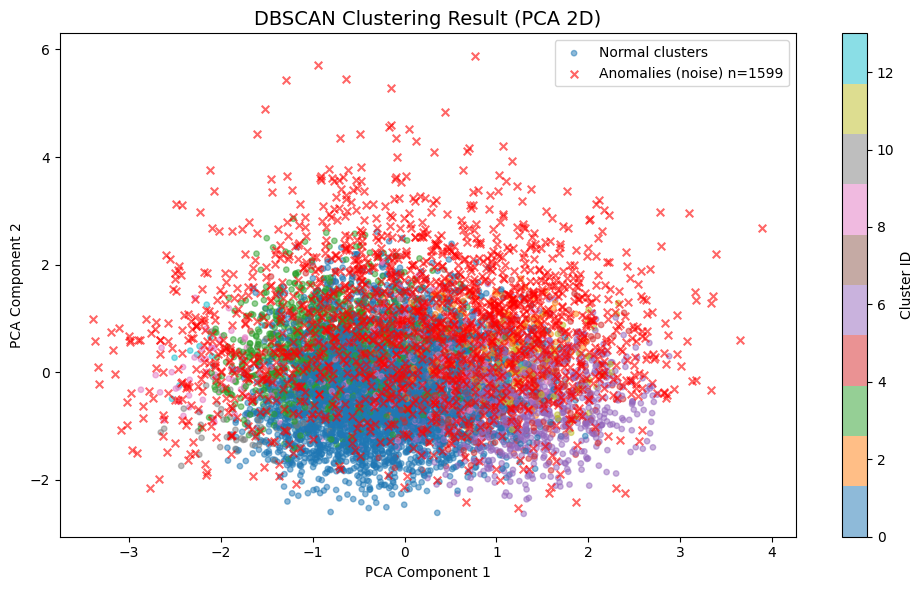

Saved: dbscan_result.png


In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))

mask_normal = db_labels != -1
scatter = plt.scatter(
    X_pca[mask_normal, 0], X_pca[mask_normal, 1],
    c=db_labels[mask_normal], cmap='tab10',
    s=15, alpha=0.5, label='Normal clusters'
)

mask_noise = db_labels == -1
plt.scatter(
    X_pca[mask_noise, 0], X_pca[mask_noise, 1],
    c='red', marker='x', s=30, alpha=0.6,
    label=f'Anomalies (noise) n={n_noise}'
)

plt.colorbar(scatter, label='Cluster ID')
plt.title('DBSCAN Clustering Result (PCA 2D)', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_result.png', dpi=150)
plt.show()
print('Saved: dbscan_result.png')

## 5. Cluster Analysis

In [5]:
# Mean feature values per cluster
summary = df.groupby('dbscan_label')[features + ['attack_detected']].mean().round(3)
print('Mean feature values per cluster:')
print(summary.to_string())

Mean feature values per cluster:
              network_packet_size  login_attempts  session_duration  ip_reputation_score  failed_logins  unusual_time_access  protocol_type_enc  encryption_enc  attack_detected
dbscan_label                                                                                                                                                                    
-1                        519.547           4.530          1421.976                0.366          1.760                0.405              1.158           0.936            0.654
 0                        501.700           3.919           694.653                0.321          1.499                0.000              1.000           1.000            0.436
 1                        492.104           3.910           698.512                0.328          1.501                0.000              1.000           0.000            0.417
 2                        531.155           4.056           611.407               

In [6]:
# Attack rate per cluster vs ground truth label
attack_rate = df.groupby('dbscan_label')['attack_detected'].agg(['mean', 'count'])
attack_rate.columns = ['Attack Rate', 'Count']
attack_rate['Attack Rate'] = (attack_rate['Attack Rate'] * 100).round(1).astype(str) + '%'
print('Attack rate per cluster:')
print(attack_rate)

Attack rate per cluster:
             Attack Rate  Count
dbscan_label                   
-1                 65.4%   1599
 0                 43.6%   1568
 1                 41.7%   2631
 2                 41.6%    303
 3                 41.9%   1078
 4                 40.0%    497
 5                 26.3%     99
 6                 40.2%    904
 7                 29.1%    175
 8                 39.2%    393
 9                 26.8%     71
 10                23.9%     92
 11                20.7%     87
 12                27.3%     11
 13                17.2%     29


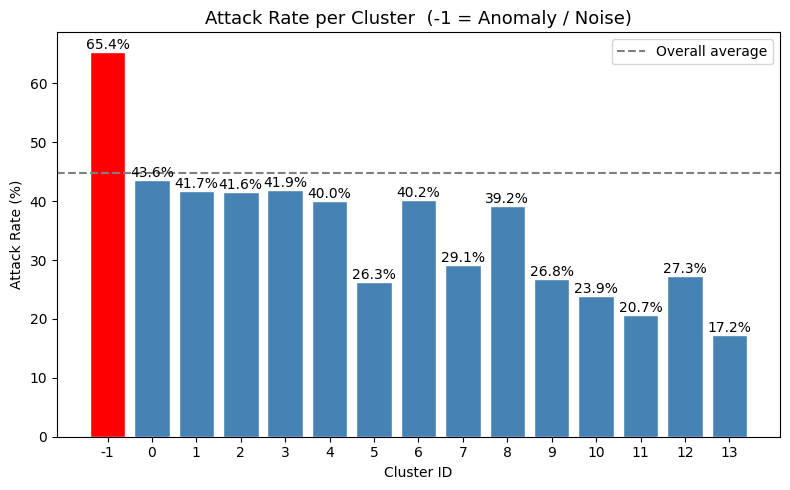

Saved: attack_rate_by_cluster.png


In [7]:
# Bar chart: attack rate per cluster
attack_pct = df.groupby('dbscan_label')['attack_detected'].mean() * 100
colors = ['red' if i == -1 else 'steelblue' for i in attack_pct.index]

plt.figure(figsize=(8, 5))
bars = plt.bar(attack_pct.index.astype(str), attack_pct.values, color=colors, edgecolor='white')
plt.axhline(y=df['attack_detected'].mean()*100, color='gray', linestyle='--', label='Overall average')
plt.title('Attack Rate per Cluster  (-1 = Anomaly / Noise)', fontsize=13)
plt.xlabel('Cluster ID')
plt.ylabel('Attack Rate (%)')
plt.legend()

for bar, val in zip(bars, attack_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('attack_rate_by_cluster.png', dpi=150)
plt.show()
print('Saved: attack_rate_by_cluster.png')